# House Price Prediction EDA and Modeling

## Loading the library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# I'll import other library throughout

## Loading Data

In [2]:
df=pd.read_csv('/kaggle/input/housedata/data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


## Basic EDA

In [3]:
df.shape

(4600, 18)

In [4]:
# basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [5]:
# statistical info
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [6]:
# to check fo null values
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

**which means there are no null values in our dataset**

In [7]:
# check for duplicated values
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [9]:
df.nunique()

date               70
price            1741
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
street           4525
city               44
statezip           77
country             1
dtype: int64

## Visual EDA

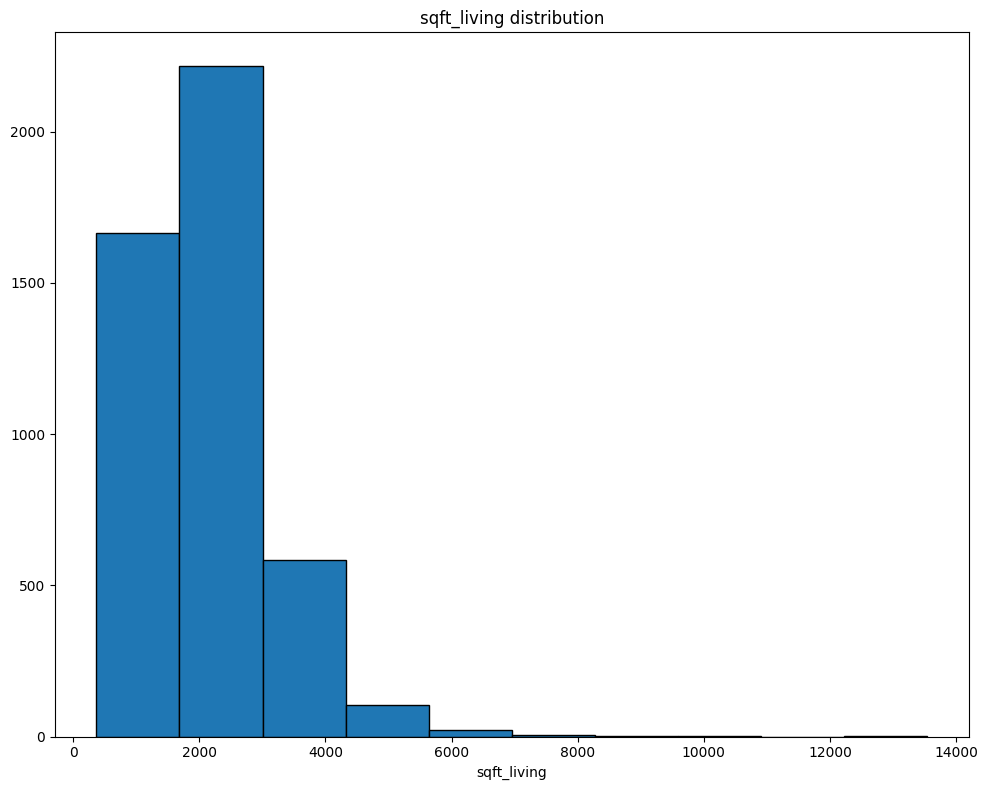

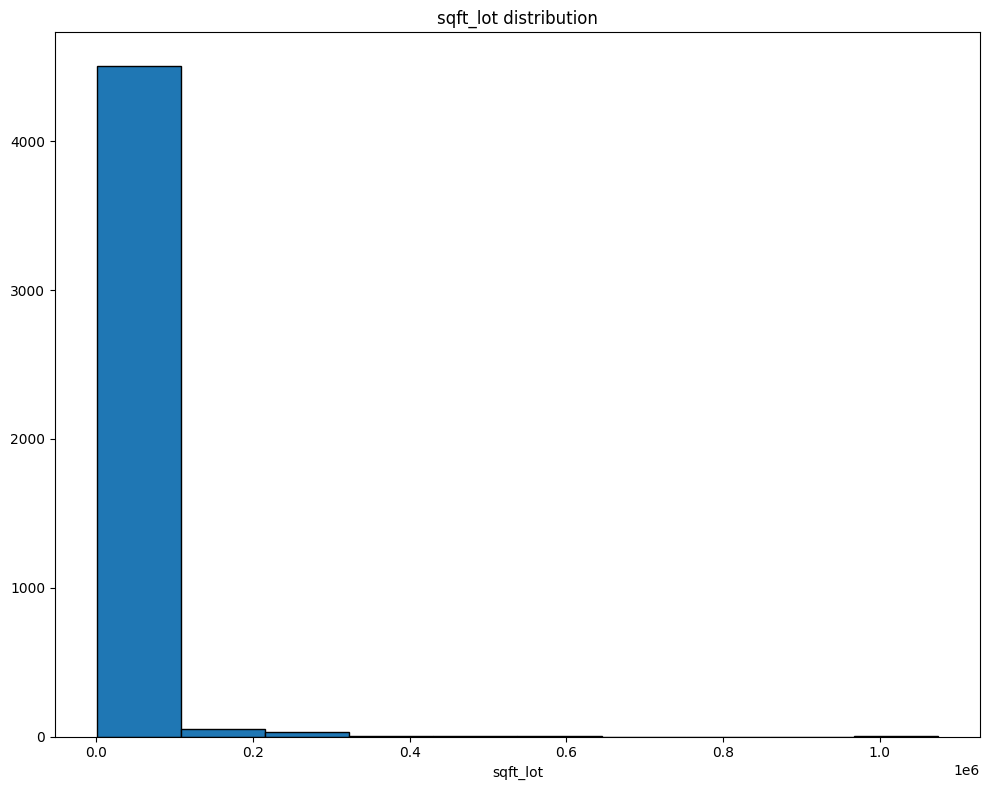

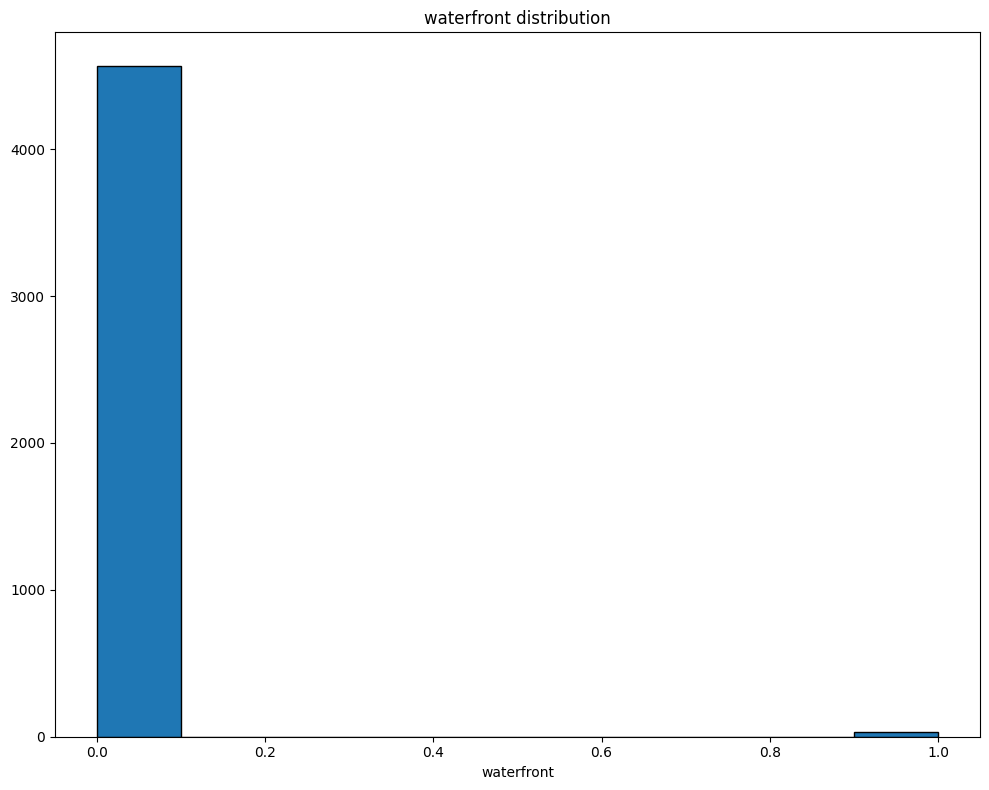

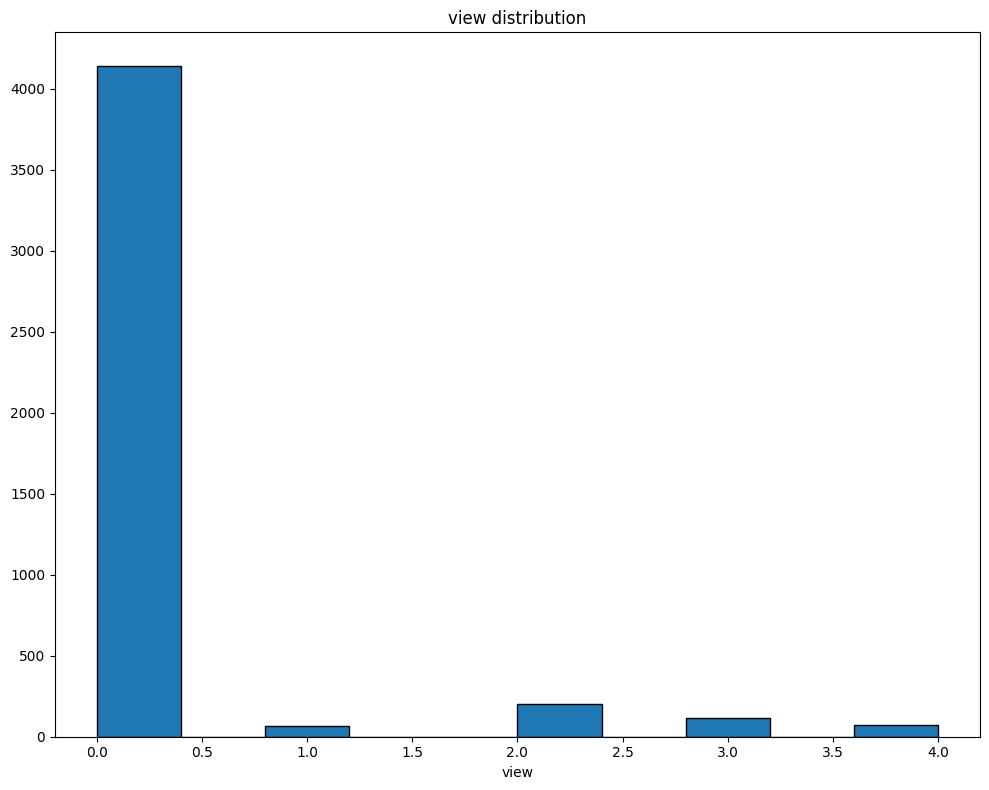

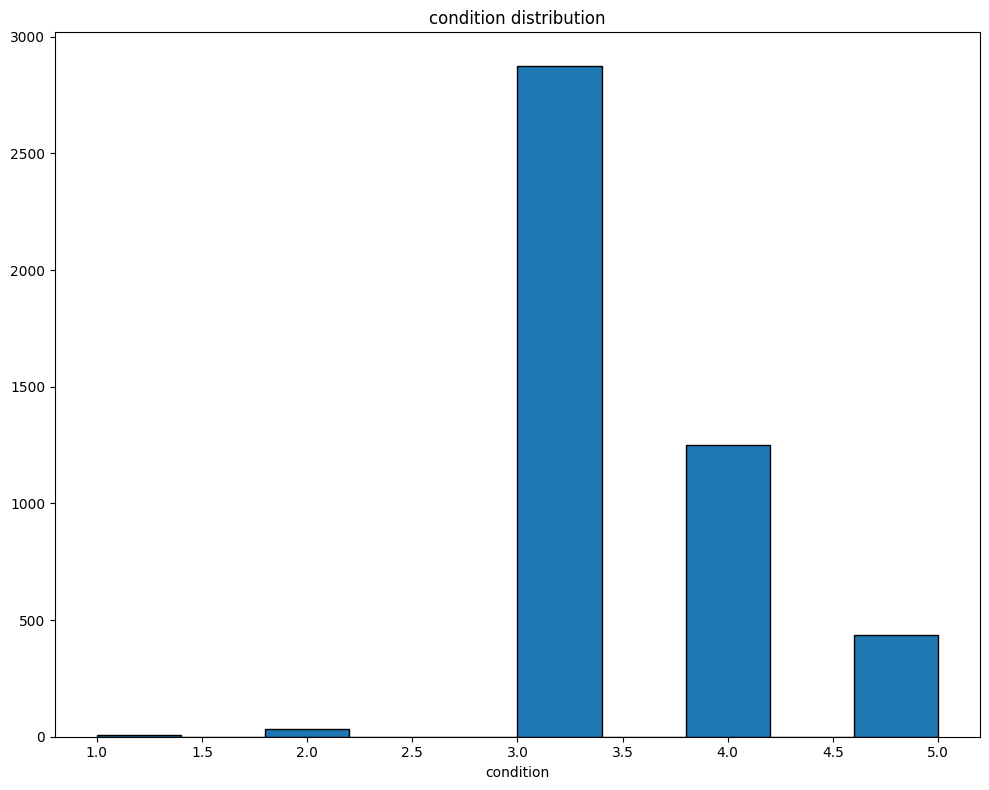

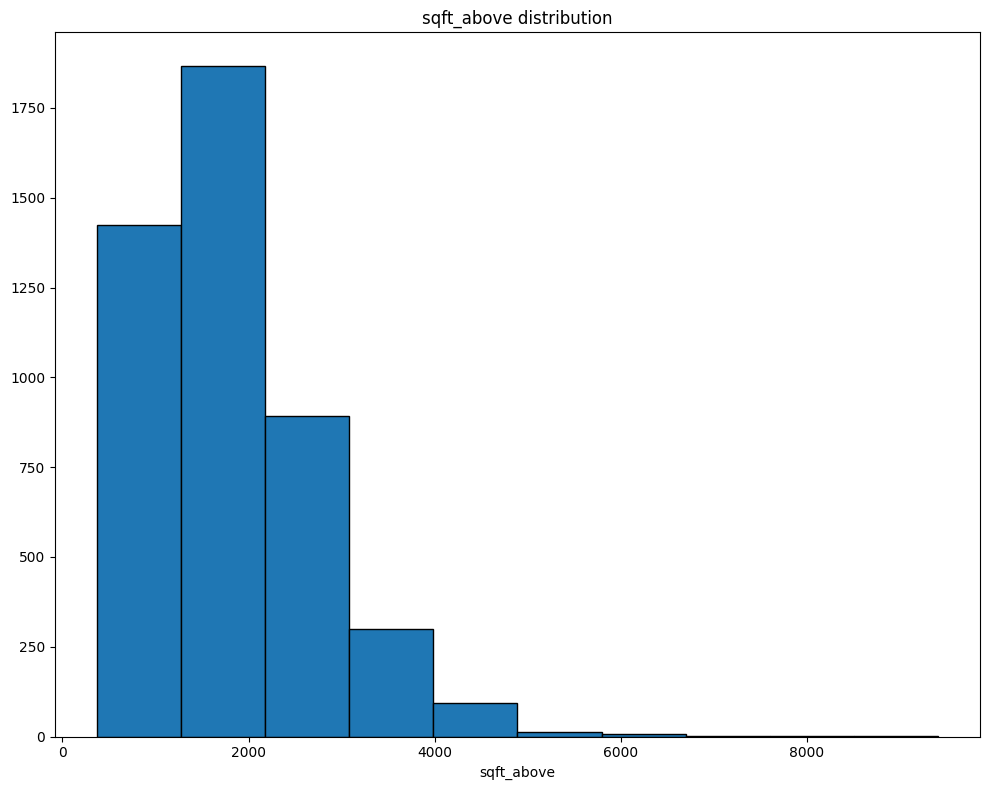

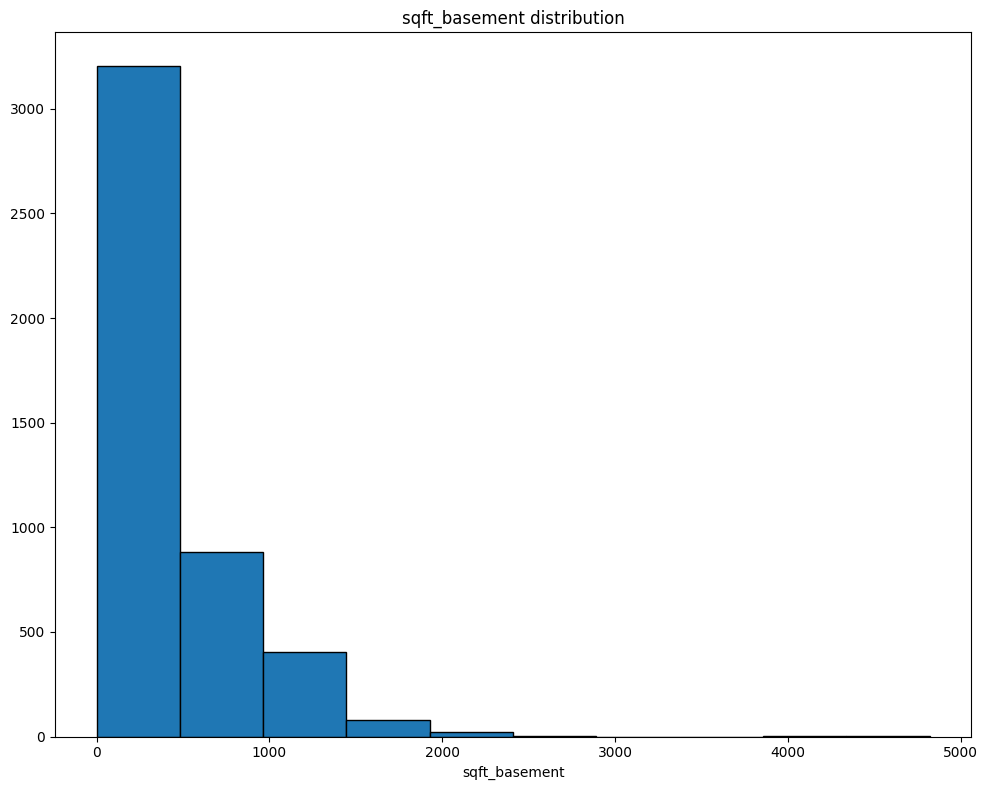

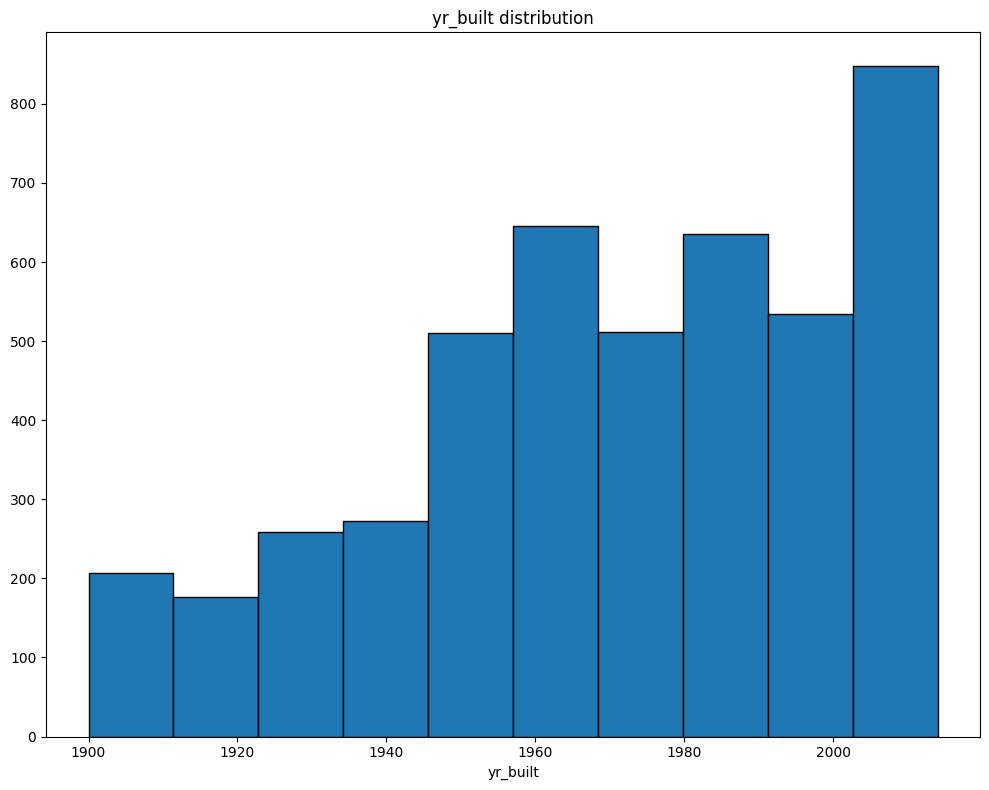

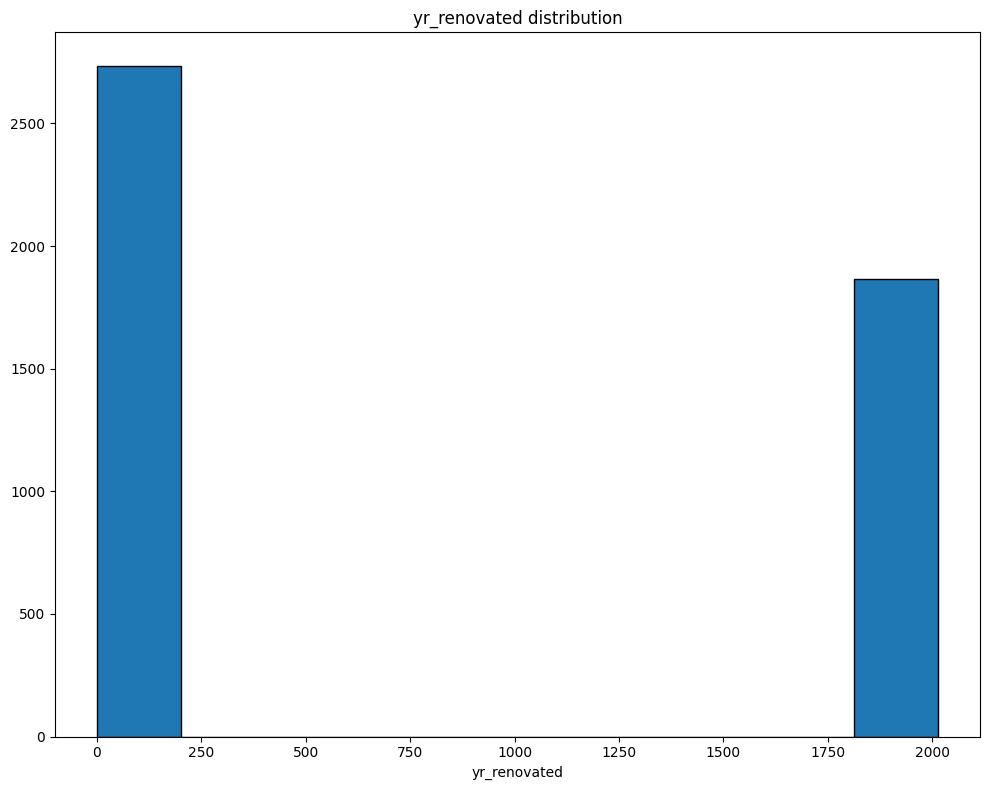

In [10]:
num_cols=df.select_dtypes(include=['int64'])
for i in num_cols:
    plt.figure(figsize=(10,8))
    plt.title(f"{i} distribution")
    plt.hist(df[i],edgecolor='black')
    plt.xlabel(f"{i}")
    plt.tight_layout()
    plt.show()

The different numericals shows us different distribution like yr_renovated feature shows us there are many house which have not been renovated thats why the graph near 0 is high

Different features will conclude different situation on our dataset here

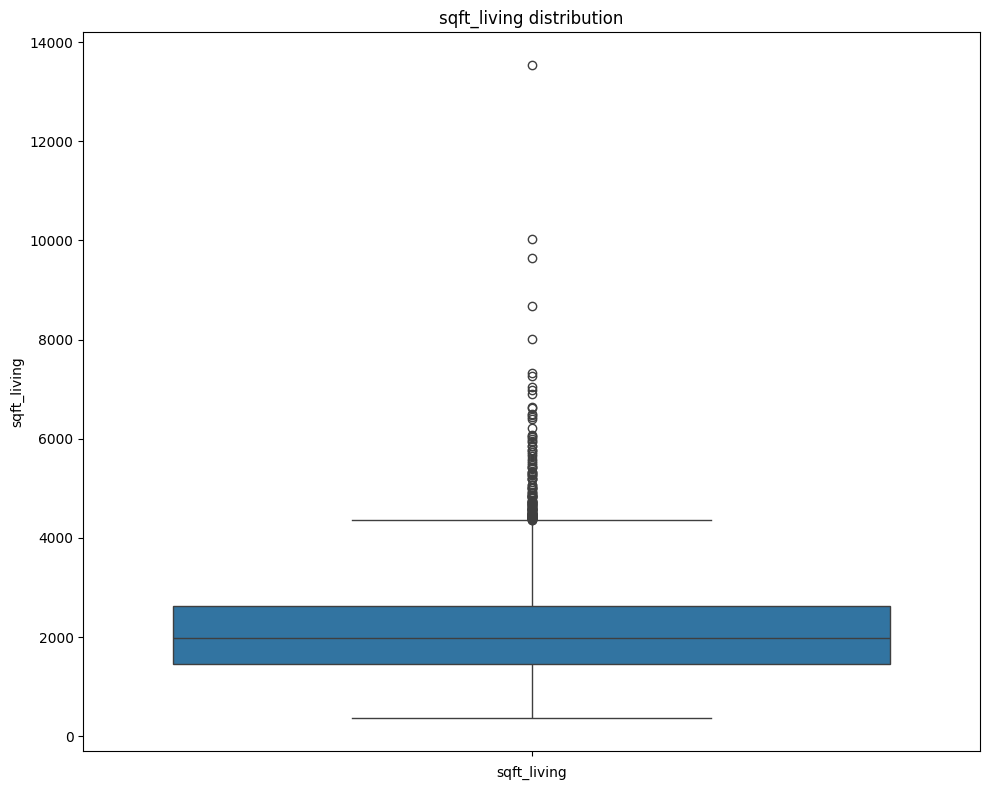

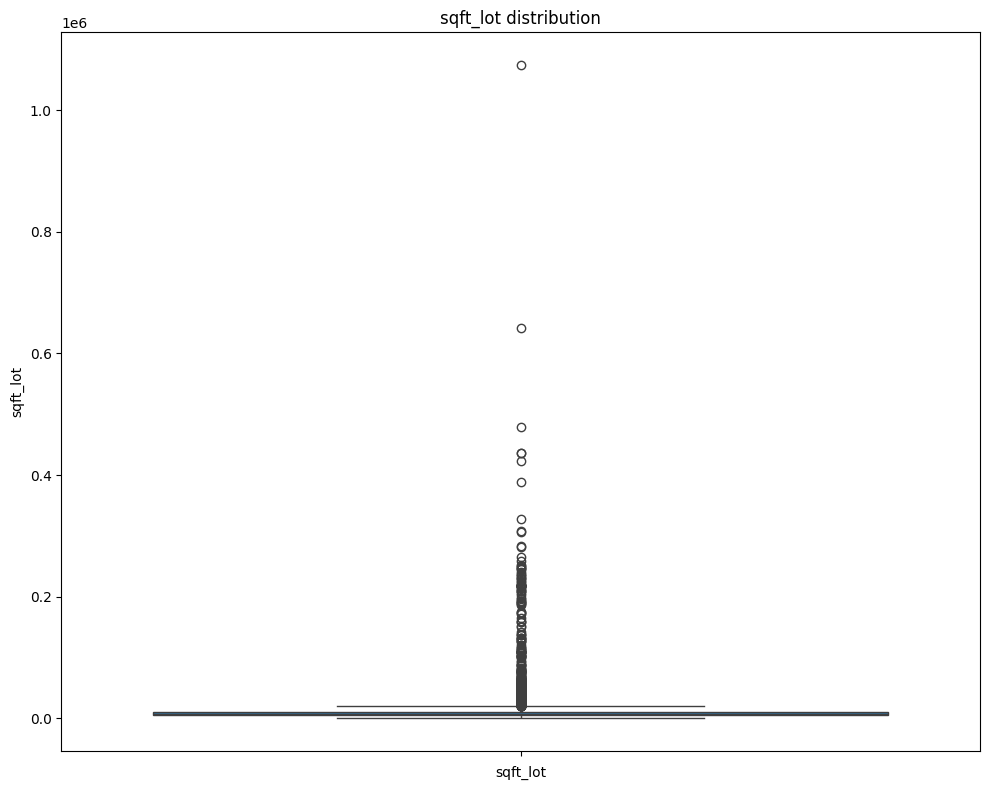

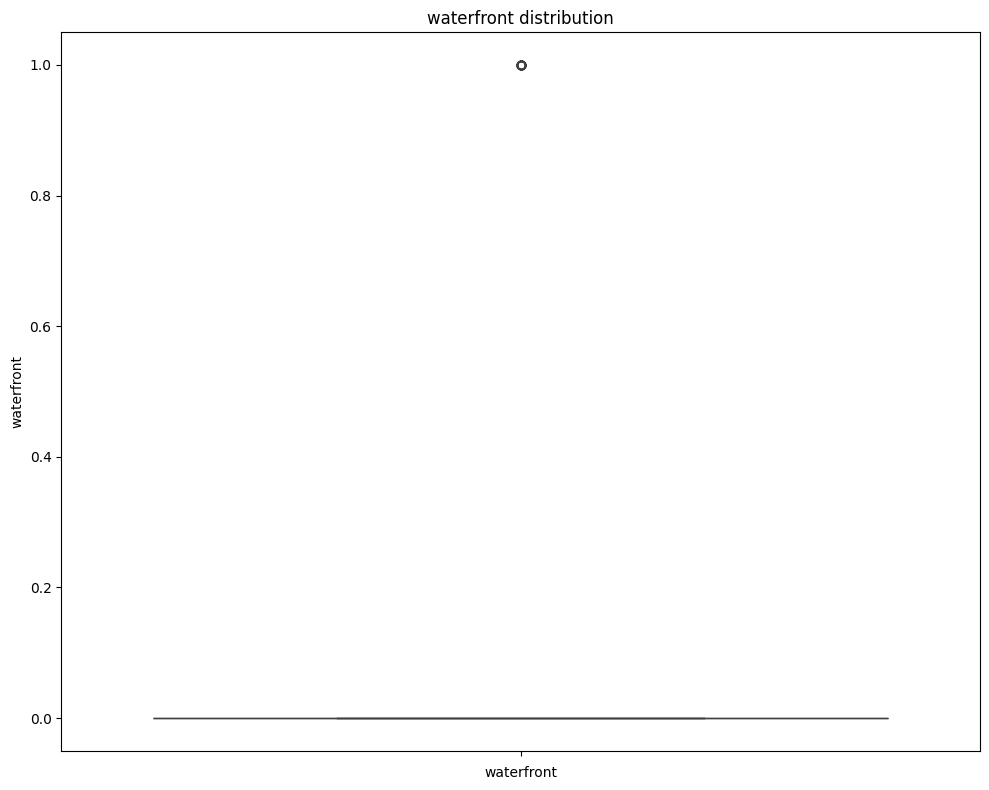

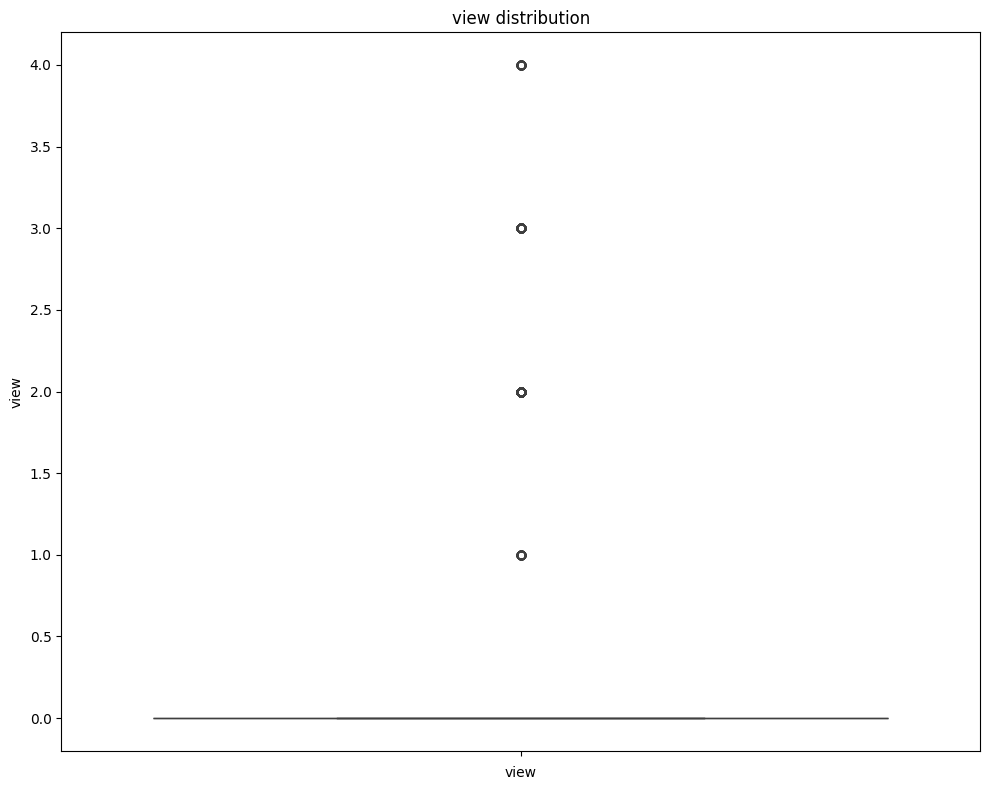

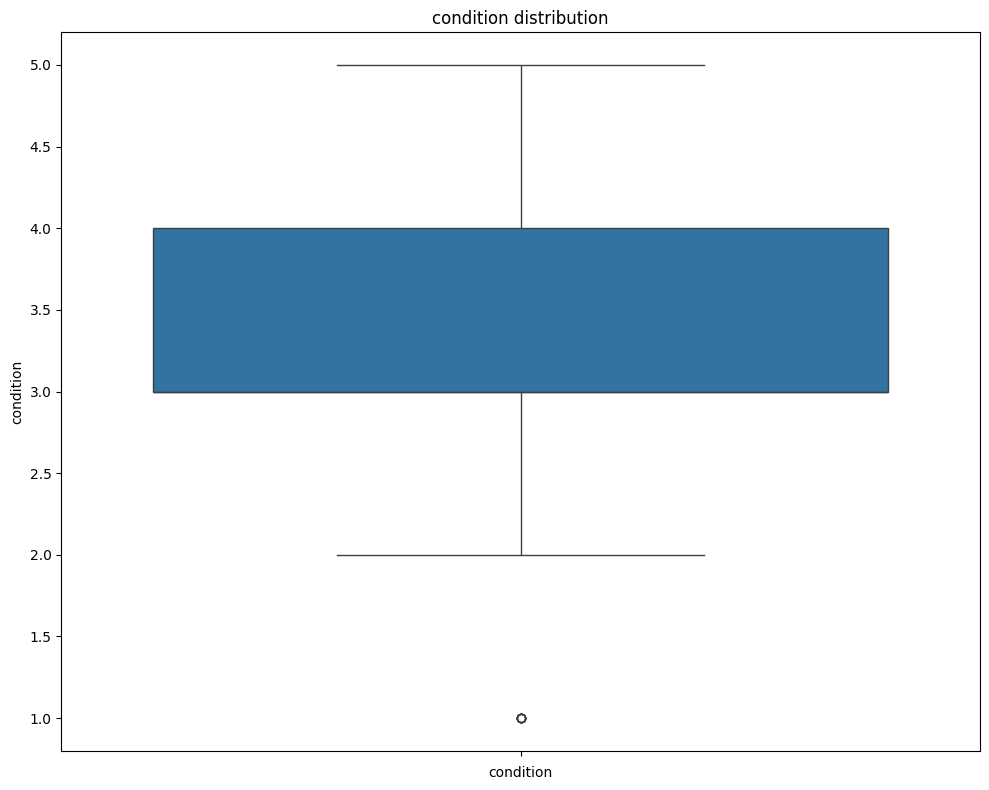

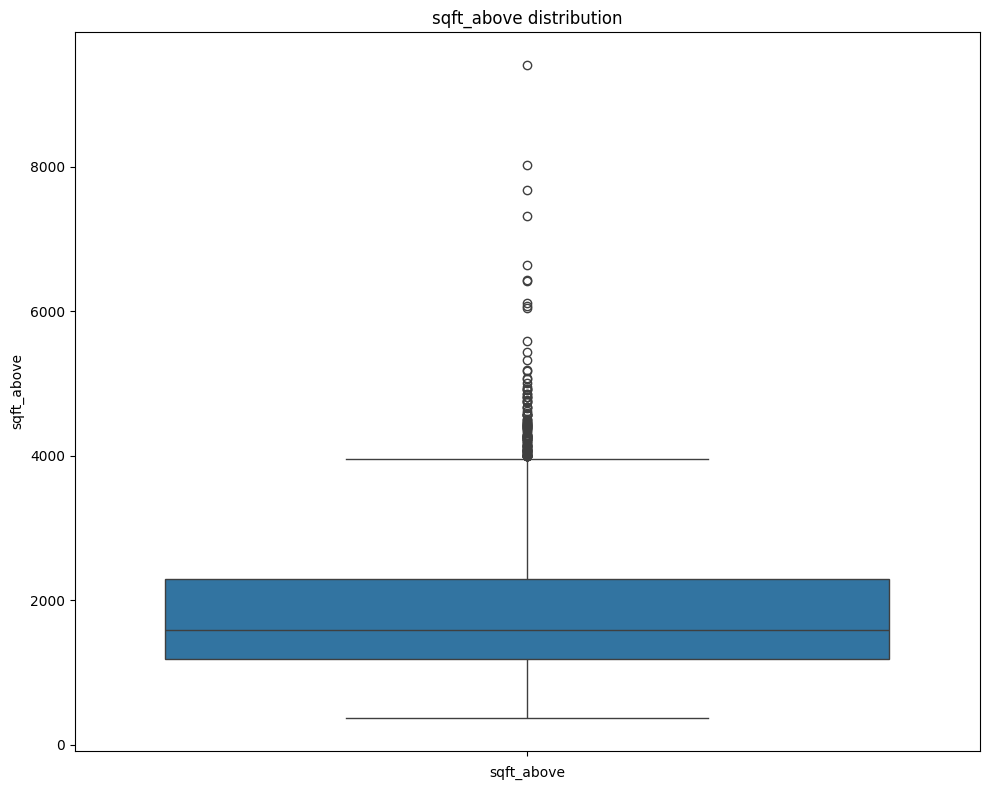

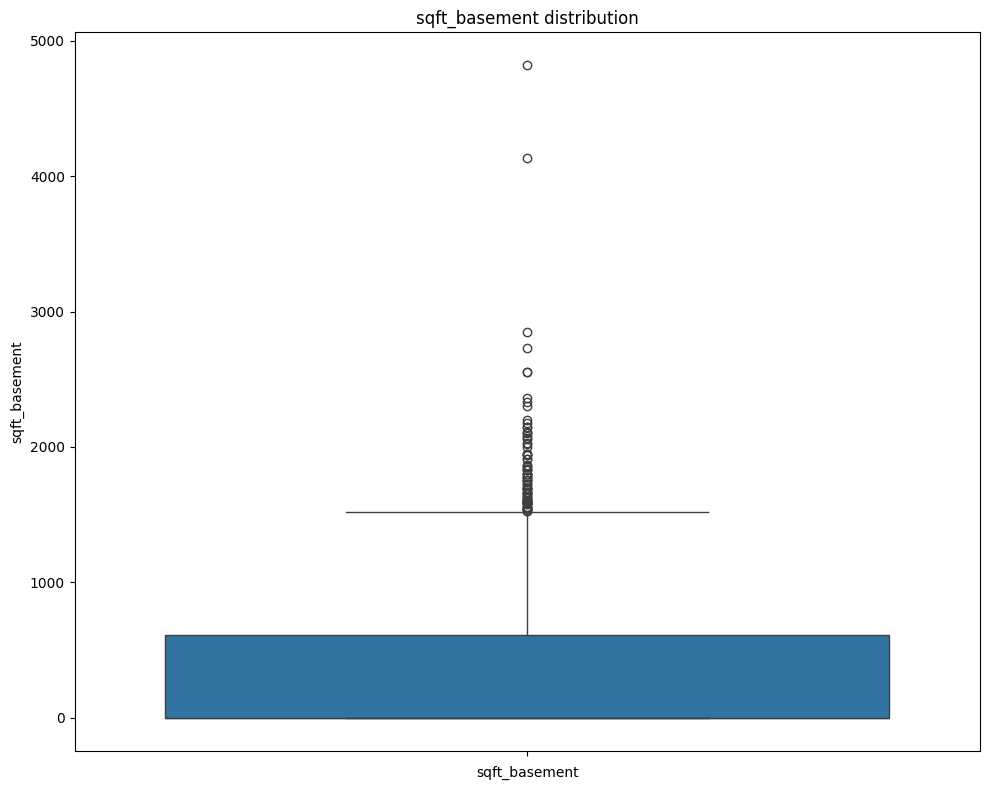

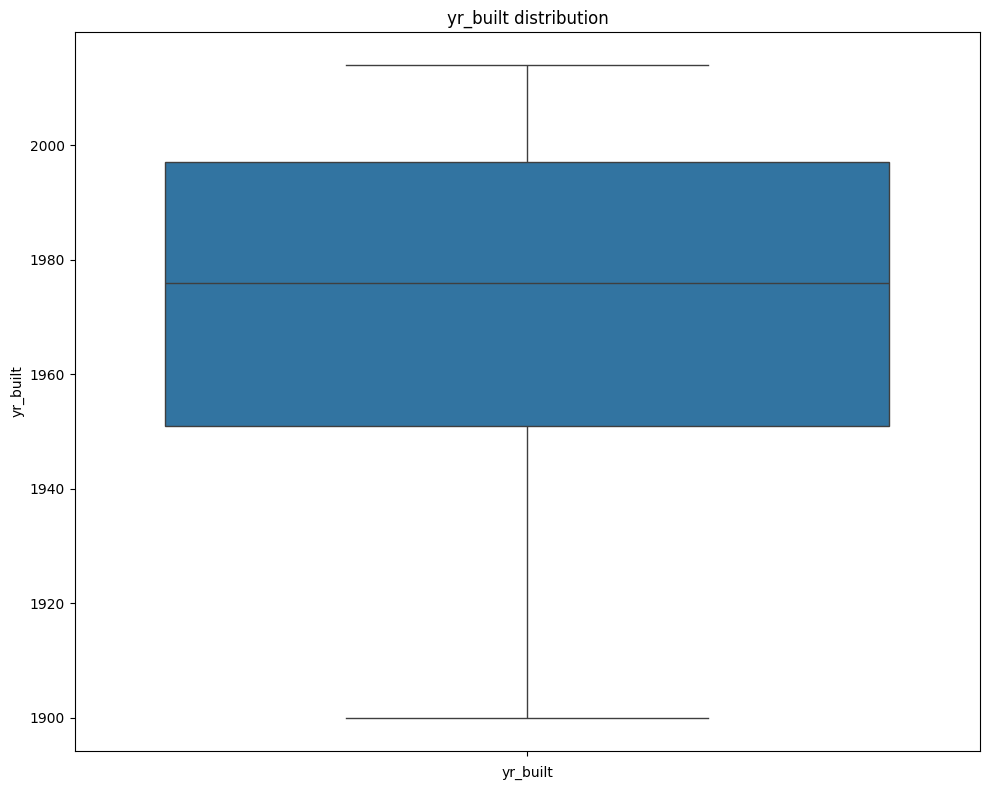

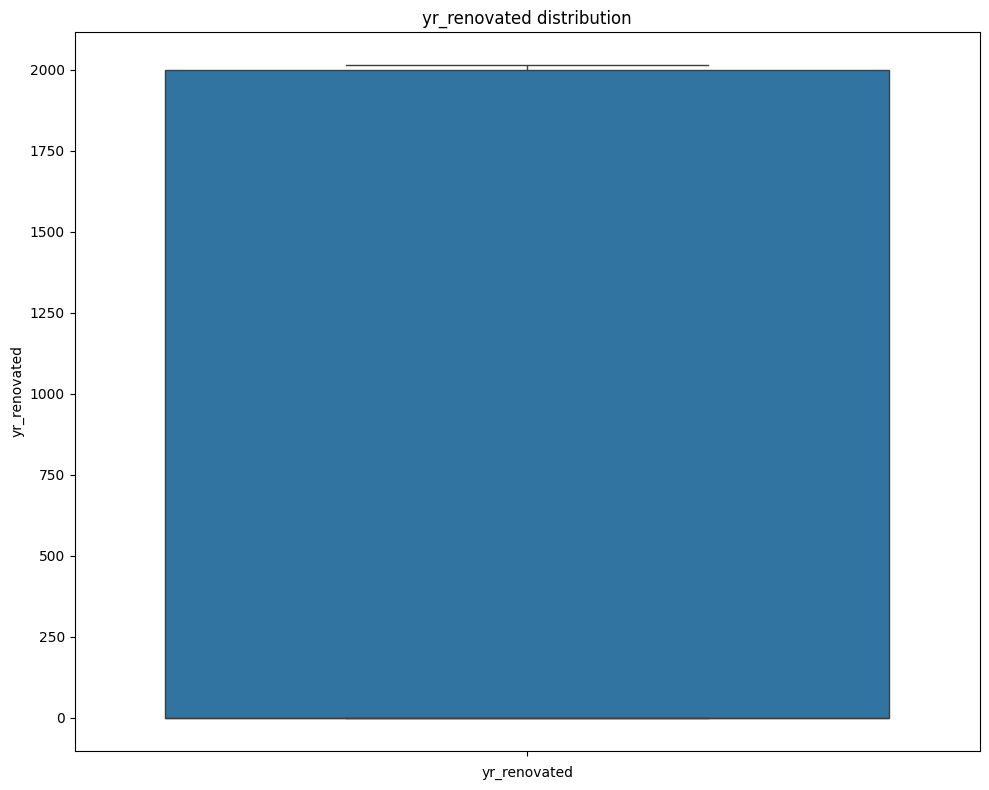

In [11]:
for i in num_cols:
    plt.figure(figsize=(10,8))
    plt.title(f"{i} distribution")
    sns.boxplot(df[i])
    plt.xlabel(f"{i}")
    plt.tight_layout()
    plt.show()

Almost every numerical feature has outliers except yr_built and yr_renovated

### Price relation with different features

In [12]:
cat_cols=df.select_dtypes(include=['object'])
cat_cols

,date,street,city,statezip,country
0,2014-05-02 00:00:00,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...
4595,2014-07-09 00:00:00,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,5148 S Creston St,Seattle,WA 98178,USA


In [13]:
a=df.groupby("city")[["price"]].mean()

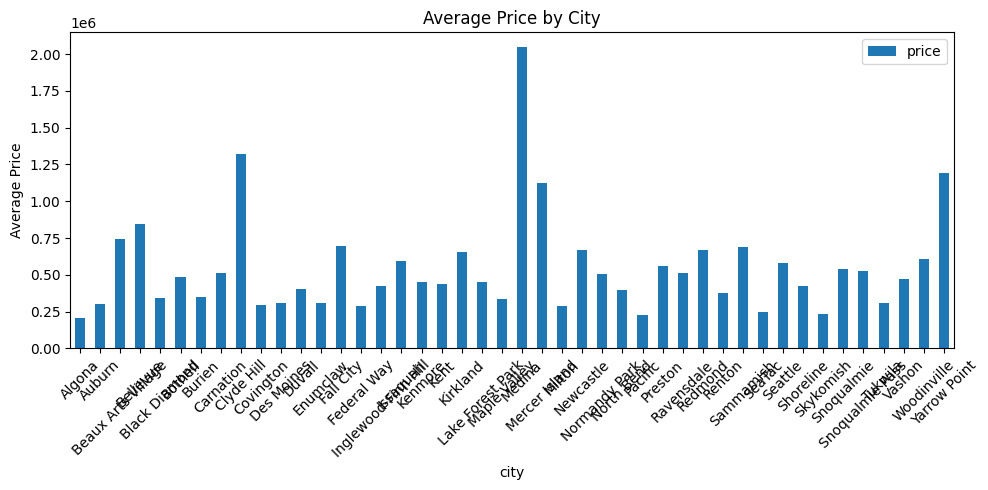

In [14]:
a.plot(kind="bar", figsize=(10,5), title="Average Price by City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

which shows us city effects price very much

In [15]:
c=df.groupby("statezip")[["price"]].mean()

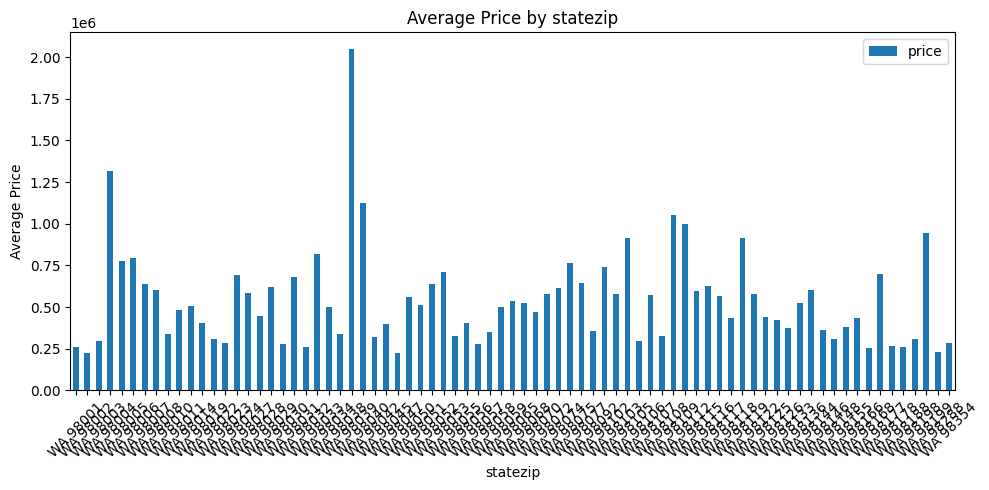

In [16]:
c.plot(kind="bar", figsize=(10,5), title="Average Price by statezip")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data preprocessing

In [17]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [18]:
for i in cat_cols:
    df[i]=le.fit_transform(df[i])

### Correlation Heatmap

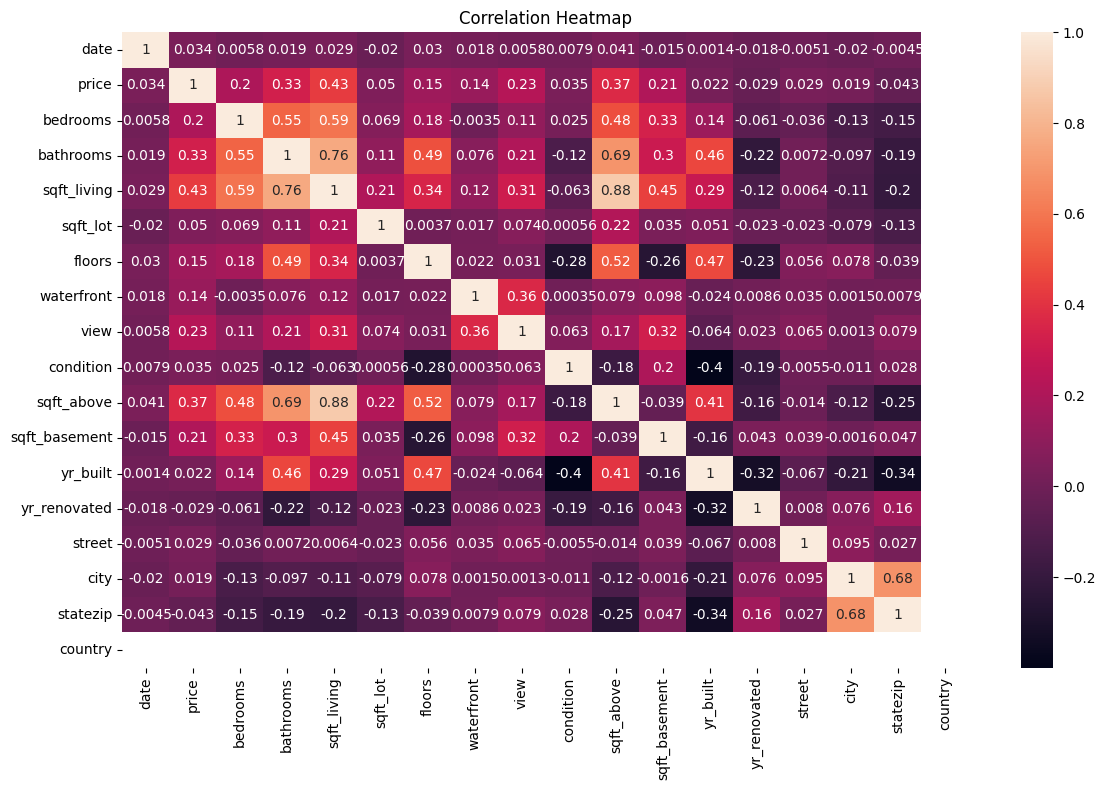

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [20]:
corr=df.corr()['price']

In [21]:
corr

date             0.033906
price            1.000000
bedrooms         0.200336
bathrooms        0.327110
sqft_living      0.430410
sqft_lot         0.050451
floors           0.151461
waterfront       0.135648
view             0.228504
condition        0.034915
sqft_above       0.367570
sqft_basement    0.210427
yr_built         0.021857
yr_renovated    -0.028774
street           0.029366
city             0.018625
statezip        -0.043385
country               NaN
Name: price, dtype: float64

In [22]:
corr_abs=corr.abs().sort_values(ascending=False)
corr_abs

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
statezip         0.043385
condition        0.034915
date             0.033906
street           0.029366
yr_renovated     0.028774
yr_built         0.021857
city             0.018625
country               NaN
Name: price, dtype: float64

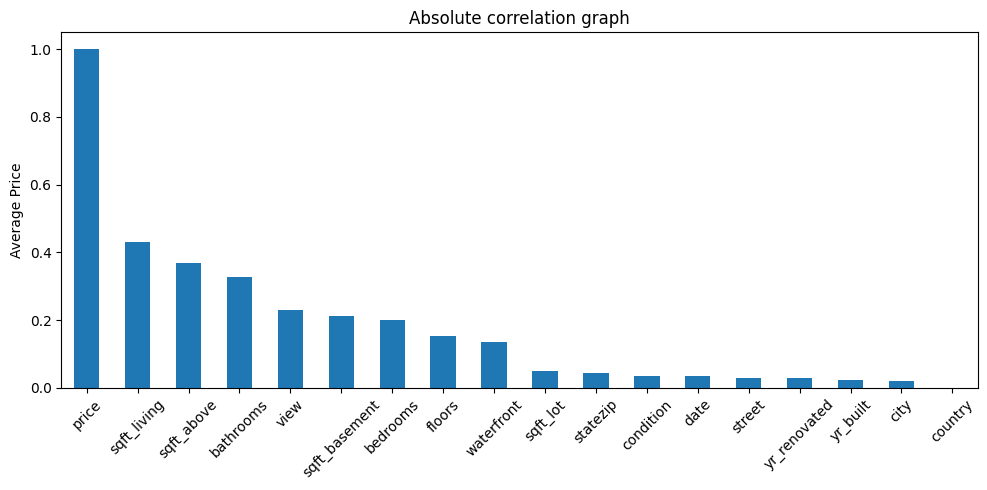

In [23]:
corr_abs.plot(kind='bar',figsize=(10,5), title="Absolute correlation graph")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

So in short we made a correlation heatmap and then sort the absolute values of them and plot bar chart to get the top most realted feature to be selected for our model 

In [24]:
selected_features=corr_abs[corr_abs>=0.2].index

In [25]:
selected_features

Index(['price', 'sqft_living', 'sqft_above', 'bathrooms', 'view',
       'sqft_basement', 'bedrooms'],
      dtype='object')

In [26]:
final_df=df[selected_features]
final_df

,price,sqft_living,sqft_above,bathrooms,view,sqft_basement,bedrooms
0,3.130000e+05,1340,1340,1.50,0,0,3.0
1,2.384000e+06,3650,3370,2.50,4,280,5.0
2,3.420000e+05,1930,1930,2.00,0,0,3.0
3,4.200000e+05,2000,1000,2.25,0,1000,3.0
4,5.500000e+05,1940,1140,2.50,0,800,4.0
...,...,...,...,...,...,...,...
4595,3.081667e+05,1510,1510,1.75,0,0,3.0
4596,5.343333e+05,1460,1460,2.50,0,0,3.0
4597,4.169042e+05,3010,3010,2.50,0,0,3.0
4598,2.034000e+05,2090,1070,2.00,0,1020,4.0


## Spliting our data

In [27]:
X=final_df.drop(columns=['price'])
y=df['price']

In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)

### Scaling

here we can see our data is not in a same range so we have to scale them so our model can understand it better way

In [29]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [30]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

The dataset is split before scaling to prevent data leakage. Feature scaling is applied only to input variables, while the target variable is kept in its original scale for interpretability.

## Modeling

In [31]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [32]:
lr.fit(x_train_scaled,y_train)

LinearRegression()

In [33]:
y_pred=lr.predict(x_test_scaled)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")


MAE  : 220189.52
RMSE : 994642.39
R²   : 0.030
